# ASR Pipeline — Evaluation Notebook
Evaluates Faster-Whisper with the preprocessing pipeline from the project.
Metrics: **WER** (Word Error Rate) and **RTF** (Real Time Factor).

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install faster-whisper jiwer librosa noisereduce pyloudnorm tqdm -q

import json, os, re, tarfile, time
import numpy as np
import librosa
import jiwer
import noisereduce as nr
import pyloudnorm as pyln
import torch
import matplotlib.pyplot as plt
from faster_whisper import WhisperModel
from tqdm import tqdm

print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.2 MB/s eta 0:00:00
Device: cuda


## 2. Configuration
Edit this cell to switch between pipeline configurations.

In [31]:
# ── Dataset ───────────────────────────────────────────────────────────────
ARCHIVE_PATH   = "/content/drive/MyDrive/Диплом/ruls_data.tar.gz"
MAX_FILES      = 100   # set to None to evaluate the full test set

# ── Model (matches app/config.py) ────────────────────────────────────────
MODEL_SIZE     = "large-v3"   # tiny | base | small | medium | large-v2 | large-v3
QUANTIZATION   = "int8"       # int8 | int8_float16 | float16 | float32
VAD_ENABLED    = True
TARGET_SR      = 16_000

# ── Pre-processing ────────────────────────────────────────────────────────
LOUDNESS_NORMALIZATION_ENABLED = True
LOUDNESS_METHOD                = "lufs"   # lufs | peak | rms
LOUDNESS_TARGET                = -23.0    # LUFS (EBU R128)

DENOISING_ENABLED  = True
DENOISE_STATIONARY = True    # True = constant noise; False = adaptive
DENOISE_PROP_DECREASE = 0.9  # fraction of noise to remove [0.0 – 1.0]

## 3. Pipeline

In [32]:
# ── Model ─────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model  = WhisperModel(MODEL_SIZE, device=DEVICE, compute_type=QUANTIZATION)
print(f"Loaded  model={MODEL_SIZE}  device={DEVICE}  compute_type={QUANTIZATION}")


# ── Pre-processing ────────────────────────────────────────────────────────
def normalize_loudness(audio: np.ndarray, sr: int) -> np.ndarray:
    if len(audio) == 0 or np.max(np.abs(audio)) == 0:
        return audio
    if LOUDNESS_METHOD == "lufs":
        meter   = pyln.Meter(sr)
        current = meter.integrated_loudness(audio)
        if np.isnan(current) or current == -np.inf:
            # fallback: peak normalize
            peak = np.max(np.abs(audio))
            audio = audio * (0.95 / peak) if peak > 0 else audio
        else:
            audio = pyln.normalize.loudness(audio, current, LOUDNESS_TARGET)
    elif LOUDNESS_METHOD == "peak":
        peak  = np.max(np.abs(audio))
        audio = audio * (0.95 / peak) if peak > 0 else audio
    elif LOUDNESS_METHOD == "rms":
        rms   = np.sqrt(np.mean(audio ** 2))
        audio = audio * (0.1 / rms) if rms > 0 else audio
    return np.clip(audio, -1.0, 1.0).astype(np.float32)


def preprocess(audio: np.ndarray, sr: int) -> np.ndarray:
    if DENOISING_ENABLED:
        audio = nr.reduce_noise(y=audio, sr=sr,
                                stationary=DENOISE_STATIONARY,
                                prop_decrease=DENOISE_PROP_DECREASE)

    if LOUDNESS_NORMALIZATION_ENABLED:
        audio = normalize_loudness(audio, sr)

    return audio


# ── Transcription ─────────────────────────────────────────────────────────
def transcribe(audio: np.ndarray) -> str:
    segments, _ = model.transcribe(audio, vad_filter=VAD_ENABLED)
    return "".join(s.text for s in segments)


# ── Text normalisation (for WER) ──────────────────────────────────────────
def clean(text: str) -> str:
    text = re.sub(r"[^\w\s]", "", text, flags=re.UNICODE)
    return text.lower().strip()

Loaded  model=large-v3  device=cuda  compute_type=int8


## 4. Evaluation

In [33]:
wer_list, rtf_list = [], []

with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
    members = tar.getmembers()

    # Load manifest
    manifest_member = next(m for m in members if m.name == "test/manifest.json")
    tar.extract(manifest_member, path="/content/tmp", filter="data")
    with open("/content/tmp/test/manifest.json", encoding="utf-8") as f:
        entries = [json.loads(line) for line in f]

    total = len(entries) if MAX_FILES is None else min(MAX_FILES, len(entries))
    print(f"Evaluating {total} / {len(entries)} files")

    for entry in tqdm(entries[:total]):
        filename = os.path.basename(entry["audio_filepath"])
        member   = next((m for m in members if m.name.endswith(filename)), None)
        if member is None:
            continue

        tar.extract(member, path="/content/tmp_audio", filter="data")
        audio_path = f"/content/tmp_audio/{member.name}"

        audio, sr = librosa.load(audio_path, sr=TARGET_SR)
        duration   = entry["duration"]

        t0 = time.perf_counter()
        audio      = preprocess(audio, sr)
        hypothesis = clean(transcribe(audio))
        elapsed    = time.perf_counter() - t0

        reference  = clean(entry["text"])
        wer_list.append(jiwer.wer(reference, hypothesis))
        rtf_list.append(elapsed / duration if duration > 0 else 0)

        os.remove(audio_path)

!rm -rf /content/tmp /content/tmp_audio

print(f"\nWER : {np.mean(wer_list):.2%}")
print(f"RTF : {np.mean(rtf_list):.3f}")

Evaluating 100 / 1352 files


  3%|▎         | 3/100 [00:09<05:39,  3.50s/it]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
  6%|▌         | 6/100 [00:17<04:43,  3.02s/it]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
  7%|▋         | 7/100 [00:18<03:51,  2.49s/it]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
  9%|▉         | 9/100 [00:21<03:10,  2.09s/it]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
 10%|█         | 10/100 [00:26<04:17,  2.86s/it]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarn


WER : 9.72%
RTF : 0.258


## 5. Results

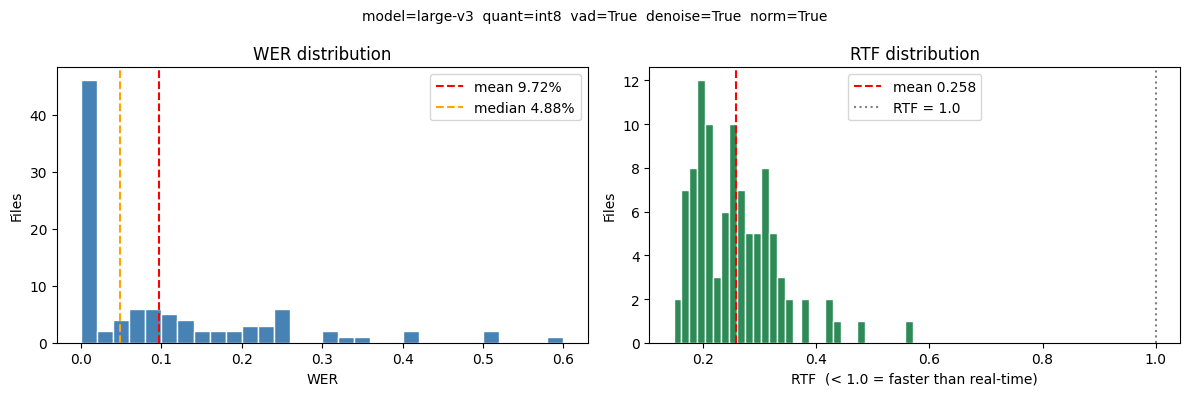


Metric         Mean   Median      P90
--------------------------------------
WER          9.72%   4.88%  25.00%
RTF           0.258    0.251    0.338

Files evaluated : 100


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"model={MODEL_SIZE}  quant={QUANTIZATION}  vad={VAD_ENABLED}  "
    f"denoise={DENOISING_ENABLED}  norm={LOUDNESS_NORMALIZATION_ENABLED}",
    fontsize=10
)

# WER distribution
axes[0].hist(wer_list, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(np.mean(wer_list), color="red", linestyle="--",
                label=f"mean {np.mean(wer_list):.2%}")
axes[0].axvline(np.median(wer_list), color="orange", linestyle="--",
                label=f"median {np.median(wer_list):.2%}")
axes[0].set_title("WER distribution")
axes[0].set_xlabel("WER")
axes[0].set_ylabel("Files")
axes[0].legend()

# RTF distribution
axes[1].hist(rtf_list, bins=30, color="seagreen", edgecolor="white")
axes[1].axvline(np.mean(rtf_list), color="red", linestyle="--",
                label=f"mean {np.mean(rtf_list):.3f}")
axes[1].axvline(1.0, color="gray", linestyle=":", label="RTF = 1.0")
axes[1].set_title("RTF distribution")
axes[1].set_xlabel("RTF  (< 1.0 = faster than real-time)")
axes[1].set_ylabel("Files")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n{'Metric':<10} {'Mean':>8} {'Median':>8} {'P90':>8}")
print("-" * 38)
print(f"{'WER':<10} {np.mean(wer_list):>7.2%} {np.median(wer_list):>7.2%} {np.percentile(wer_list, 90):>7.2%}")
print(f"{'RTF':<10} {np.mean(rtf_list):>8.3f} {np.median(rtf_list):>8.3f} {np.percentile(rtf_list, 90):>8.3f}")
print(f"\nFiles evaluated : {len(wer_list)}")

## 6. Compare configurations
Run the **Config** and **Evaluation** cells with different settings, collect results here, then plot a comparison.

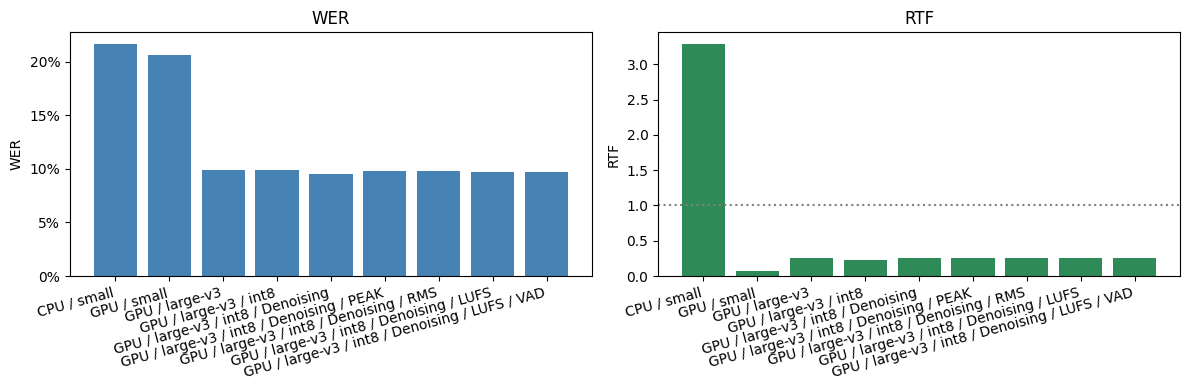

In [38]:
results = [
    {"label": "CPU / small", "wer": 0.2164, "rtf": 3.287},
    {"label": "GPU / small", "wer": 0.2057, "rtf": 0.079},
    {"label": "GPU / large-v3", "wer": 0.0989, "rtf": 0.251},
    {"label": "GPU / large-v3 / int8", "wer": 0.0989, "rtf": 0.234},
    {"label": "GPU / large-v3 / int8 / Denoising", "wer": 0.0953, "rtf": 0.258},
    {"label": "GPU / large-v3 / int8 / Denoising / PEAK", "wer": 0.0978, "rtf": 0.255},
    {"label": "GPU / large-v3 / int8 / Denoising / RMS", "wer": 0.0980, "rtf": 0.254},
    {"label": "GPU / large-v3 / int8 / Denoising / LUFS", "wer": 0.0972, "rtf": 0.256},
    {"label": "GPU / large-v3 / int8 / Denoising / LUFS / VAD", "wer": 0.0972, "rtf": 0.258},
]

if len(results) < 2:
    print("Add at least two rows to results[] to see a comparison chart.")
else:
    labels = [r["label"] for r in results]
    wers   = [r["wer"]   for r in results]
    rtfs   = [r["rtf"]   for r in results]
    x      = np.arange(len(labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(x, wers, color="steelblue")
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha="right")
    ax1.set_title("WER"); ax1.set_ylabel("WER")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

    ax2.bar(x, rtfs, color="seagreen")
    ax2.axhline(1.0, color="gray", linestyle=":")
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha="right")
    ax2.set_title("RTF"); ax2.set_ylabel("RTF")

    plt.tight_layout()
    plt.show()